# Exact Solution Methods: Value & Policy Iteration

Interactive companion to **CMM26 RL Lecture 1, slides 30--36**.

We implement **Value Iteration** and **Policy Iteration** on the classic 4$\times$3 grid world to build intuition for:
- **Value functions** -- how good is each state?
- **Bellman equation** -- the recursive relationship between state values
- **Value Iteration** -- find optimal values by repeated Bellman updates
- **Policy Iteration** -- evaluate a policy, improve it, repeat

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print('ipywidgets not available -- will use static plots')

---
## The Grid World

A 4$\times$3 grid with **stochastic** transitions:

| Element | Location | Description |
|---------|----------|-------------|
| Start | (1, 1) bottom-left | Agent begins here |
| Goal | (4, 3) top-right | Terminal, reward = **+1** |
| Pit | (4, 2) | Terminal, reward = **-1** |
| Wall | (2, 2) | Impassable obstacle |

**Actions:** North, East, South, West

**Stochastic transitions (noise = 0.2):** intended direction with prob 0.8; slip left or right (perpendicular) with prob 0.1 each. Hitting a wall or boundary means you stay in place.

**Discount factor:** $\gamma = 0.9$

In [2]:
class GridWorld:
    """4x3 stochastic grid world (Russell & Norvig)."""
    ACTION_NAMES = ['N', 'E', 'S', 'W']
    DELTAS = {0: (0, 1), 1: (1, 0), 2: (0, -1), 3: (-1, 0)}

    def __init__(self, noise=0.2, gamma=0.9):
        self.cols, self.rows = 4, 3
        self.noise = noise
        self.gamma = gamma
        self.walls = {(1, 1)}
        self.terminals = {(3, 2): +1.0, (3, 1): -1.0}
        self.start = (0, 0)
        self.states = [(x, y) for x in range(self.cols)
                       for y in range(self.rows) if (x, y) not in self.walls]
        self.nonterminal = [s for s in self.states if s not in self.terminals]

    def _move(self, state, direction):
        """Try to move in direction. Stay if wall/OOB."""
        dx, dy = self.DELTAS[direction]
        nx, ny = state[0] + dx, state[1] + dy
        if 0 <= nx < self.cols and 0 <= ny < self.rows and (nx, ny) not in self.walls:
            return (nx, ny)
        return state

    def transitions(self, state, action):
        """Return {next_state: probability} for a state-action pair."""
        if state in self.terminals:
            return {state: 1.0}
        left, right = (action - 1) % 4, (action + 1) % 4
        result = {}
        for prob, d in [(1 - self.noise, action),
                        (self.noise / 2, left),
                        (self.noise / 2, right)]:
            ns = self._move(state, d)
            result[ns] = result.get(ns, 0) + prob
        return result

In [3]:
def draw_grid(gw, V, policy=None, ax=None, title=None, show_labels=True):
    """Draw grid world with values and optional policy arrows."""
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(6, 4.5))
        fig.patch.set_facecolor('#0e1117')
    ax.set_facecolor('#0e1117')

    for x in range(gw.cols):
        for y in range(gw.rows):
            # --- cell colour ---
            if (x, y) in gw.walls:
                fc, text = '#555', ''
            else:
                val = V[x, y]
                text = f'{val:.2f}'
                if (x, y) in gw.terminals:
                    fc = '#1a6b2a' if val > 0 else '#7b1a1a'
                elif val > 0.005:
                    t = min(val, 1.0)
                    fc = (0.04 + 0.18*t, 0.15 + 0.45*t, 0.04 + 0.12*t)
                elif val < -0.005:
                    t = min(abs(val), 1.0)
                    fc = (0.25 + 0.45*t, 0.06, 0.06)
                else:
                    fc = '#1a1a2e'

            ax.add_patch(plt.Rectangle((x+0.03, y+0.03), 0.94, 0.94,
                                        fc=fc, ec='#444', lw=1))
            # terminal highlight
            if (x, y) in gw.terminals:
                ec = '#2ecc71' if gw.terminals[(x, y)] > 0 else '#e74c3c'
                ax.add_patch(plt.Rectangle((x+0.03, y+0.03), 0.94, 0.94,
                                            fc='none', ec=ec, lw=2.5))

            has_arrow = (policy is not None and (x, y) in gw.nonterminal)
            ty = y + 0.6 if has_arrow else y + 0.5
            if text:
                ax.text(x+0.5, ty, text, ha='center', va='center',
                        color='white', fontsize=12, fontweight='bold',
                        fontfamily='monospace')
            if has_arrow:
                dx, dy = GridWorld.DELTAS[int(policy[x, y])]
                ax.annotate('',
                    xy=(x+0.5 + dx*0.25, y+0.30 + dy*0.25),
                    xytext=(x+0.5 - dx*0.05, y+0.30 - dy*0.05),
                    arrowprops=dict(arrowstyle='->', color='#ffd700',
                                    lw=2.2, mutation_scale=15))

    ax.set_xlim(0, gw.cols); ax.set_ylim(0, gw.rows)
    ax.set_aspect('equal')
    if show_labels:
        ax.set_xticks([i+0.5 for i in range(gw.cols)])
        ax.set_xticklabels(range(1, gw.cols+1), color='white')
        ax.set_yticks([i+0.5 for i in range(gw.rows)])
        ax.set_yticklabels(range(1, gw.rows+1), color='white')
        ax.tick_params(length=0)
    else:
        ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', color='white', pad=10)

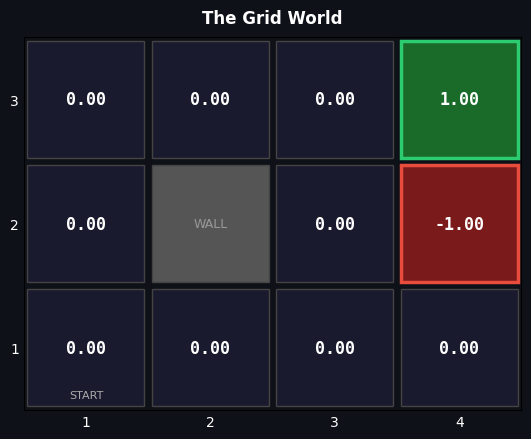

Noise = 0.2,  Discount = 0.9
11 reachable states, 4 actions


In [4]:
gw = GridWorld(noise=0.2, gamma=0.9)

V0 = np.zeros((gw.cols, gw.rows))
for s, r in gw.terminals.items():
    V0[s] = r

fig, ax = plt.subplots(figsize=(6, 4.5))
fig.patch.set_facecolor('#0e1117')
draw_grid(gw, V0, ax=ax, title='The Grid World')
ax.text(0.5, 0.1, 'START', ha='center', fontsize=8, color='#aaa')
ax.text(1.5, 1.5, 'WALL', ha='center', va='center', fontsize=9, color='#999')
plt.tight_layout()
plt.show()

print(f'Noise = {gw.noise},  Discount = {gw.gamma}')
print(f'{len(gw.states)} reachable states, 4 actions')

## Why do we need a value function?

A policy tells us **what action to take**. But to decide whether an action is good, we need to know whether it leads to **good future states**.

That creates a useful chicken-and-egg loop:

<div style="display:flex; align-items:center; justify-content:center; gap:16px; margin:18px 0; flex-wrap:wrap;">
  <div style="border:2px solid #4ea1ff; border-radius:12px; padding:12px 16px; background:#111827; color:white; min-width:180px; text-align:center;">
    <div style="font-size:18px; font-weight:700;">Policy $\pi$</div>
    <div style="font-size:13px; color:#cbd5e1;">follow these arrows</div>
  </div>
  <div style="font-size:24px; color:#fbbf24; font-weight:700;">$\Longrightarrow$</div>
  <div style="border:2px solid #34d399; border-radius:12px; padding:12px 16px; background:#111827; color:white; min-width:220px; text-align:center;">
    <div style="font-size:18px; font-weight:700;">Value function $V^\pi$</div>
    <div style="font-size:13px; color:#cbd5e1;">how good each state becomes</div>
  </div>
</div>

<div style="display:flex; align-items:center; justify-content:center; gap:16px; margin:6px 0 18px; flex-wrap:wrap;">
  <div style="border:2px solid #34d399; border-radius:12px; padding:12px 16px; background:#111827; color:white; min-width:220px; text-align:center;">
    <div style="font-size:18px; font-weight:700;">Value function $V$</div>
    <div style="font-size:13px; color:#cbd5e1;">score the possible next states</div>
  </div>
  <div style="font-size:24px; color:#fbbf24; font-weight:700;">$\Longrightarrow$</div>
  <div style="border:2px solid #4ea1ff; border-radius:12px; padding:12px 16px; background:#111827; color:white; min-width:180px; text-align:center;">
    <div style="font-size:18px; font-weight:700;">Greedy policy</div>
    <div style="font-size:13px; color:#cbd5e1;">pick the action leading to highest value</div>
  </div>
</div>

So which one comes first? In practice, we **start with a guess** and alternate:
- **Policy evaluation:** given $\pi$, compute $V^\pi$
- **Policy improvement:** given $V$, choose better actions

That evaluate $\leftrightarrow$ improve cycle is exactly what dynamic programming algorithms exploit.

---
## Value Function

Remember the overall goal of solving an MDP: find the policy that maximizes expected discounted return.

$$\max_\pi\; \underbrace{\mathbb{E}\!\left[\sum_{t=0}^{H} \gamma^t R(S_t, A_t, S_{t+1})\;\middle|\; \pi, s_0=s\right]}_{\text{this expected-return term is } V^\pi(s)}$$

So the **value function** is the score of one state under one fixed policy. Once we can compute that score, we can compare policies and search for the best one.

The **value** of a state under policy $\pi$ is the expected discounted reward from that state:

$$V^\pi(s) = \mathbb{E}_\pi \!\left[\sum_{t=0}^{H} \gamma^t R_t \;\middle|\; s_0 = s\right]$$

The **optimal value function** is the best achievable value:

$$V^*(s) = \max_\pi\, V^\pi(s)$$

### Connection to Dynamic Programming

You already know this pattern from shortest-path problems!
- **Optimal substructure:** if $A \to E \to M$ is optimal, then $A \to E$ and $E \to M$ are each optimal
- **Overlapping subproblems:** $V(v) = \min_u\, d(u,v) + V(u)$

The **Bellman optimality equation** is the same idea applied to MDPs:

$$V^*(s) = \max_a \sum_{s'} P(s'|s,a)\;\gamma\; V^*(s')$$

*The value of a state = the best action's expected discounted future value.*

### Example: compute $V^\pi$ for one fixed policy

Before searching for the *best* policy, freeze a hand-designed policy $\pi$ (similar to the sketch from lecture) and ask: **how good is each state if we commit to these arrows?**

For a fixed policy, the Bellman equation loses the $\max$:

$$V^\pi(s) = \sum_{s'} P(s'|s, \pi(s))\;\gamma\;V^\pi(s')$$

Below, the policy tries to move toward the $+1$ terminal while avoiding the $-1$ terminal. Policy evaluation repeatedly applies this update until the values stop changing.

In [ ]:
def policy_evaluation(gw, policy, max_iter=500):
    """Compute V^pi for a fixed policy by iterative evaluation."""
    V = np.zeros((gw.cols, gw.rows))
    for s, r in gw.terminals.items():
        V[s] = r

    for i in range(1, max_iter + 1):
        V_new = np.zeros_like(V)
        for s, r in gw.terminals.items():
            V_new[s] = r
        for s in gw.nonterminal:
            a = policy[s]
            V_new[s] = sum(p * gw.gamma * V[ns]
                           for ns, p in gw.transitions(s, a).items())
        if np.max(np.abs(V_new - V)) < 1e-10:
            break
        V = V_new
    return V_new, i


pi_demo = np.full((gw.cols, gw.rows), -1, dtype=int)
demo_actions = {
    (0, 2): 1, (1, 2): 1, (2, 2): 1,
    (0, 1): 0,             (2, 1): 0,
    (0, 0): 1, (1, 0): 1, (2, 0): 0, (3, 0): 3,
}
for s, a in demo_actions.items():
    pi_demo[s] = a

V_pi_demo, eval_iters = policy_evaluation(gw, pi_demo)

print(f'Policy evaluation converged in {eval_iters} iterations')
print('Hand-designed policy values V^pi:')
for y in range(gw.rows-1, -1, -1):
    row = ''
    for x in range(gw.cols):
        if (x, y) in gw.walls:
            row += '  WALL '
        else:
            row += f' {V_pi_demo[x, y]:5.2f} '
    print(f'  {row}')

V_policy_view = np.zeros_like(V_pi_demo)
for s, r in gw.terminals.items():
    V_policy_view[s] = r

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0e1117')
draw_grid(gw, V_policy_view, policy=pi_demo, ax=axes[0], title='Fixed policy π')
draw_grid(gw, V_pi_demo, policy=pi_demo, ax=axes[1], title='Computed value function V^π')
plt.tight_layout()
plt.show()

## Value Iteration Algorithm

Turn the Bellman equation into an iterative update:

1. **Init** $V_0(s) = 0$ for all states; terminal values fixed at their reward
2. **For** $k = 1, 2, \ldots$, for all non-terminal states $s$:
$$V_k(s) = \max_a \sum_{s'} P(s'|s,a)\;\gamma\; V_{k-1}(s')$$
3. **Extract policy:** $\pi^*(s) = \arg\max_a \sum_{s'} P(s'|s,a)\;\gamma\; V^*(s')$

Three things to note:
1. Need to **sweep through all states** each iteration
2. Need the **transition model** $P(s'|s,a)$
3. **Convergence guaranteed** (the Bellman operator is a contraction)

In [5]:
def value_iteration(gw, max_iter=200, verbose=True):
    """Run Value Iteration. Returns (V*, history of V at each iteration)."""
    V = np.zeros((gw.cols, gw.rows))
    history = [V.copy()]  # iteration 0: all zeros

    for k in range(1, max_iter + 1):
        V_new = np.zeros_like(V)
        for s, r in gw.terminals.items():
            V_new[s] = r
        for s in gw.nonterminal:
            V_new[s] = max(
                sum(p * gw.gamma * V[ns]
                    for ns, p in gw.transitions(s, a).items())
                for a in range(4))
        history.append(V_new.copy())
        if np.max(np.abs(V_new - V)) < 1e-10:
            if verbose:
                print(f'Converged at iteration {k}')
            break
        V = V_new
    return V_new, history


def extract_policy(gw, V):
    """Extract greedy policy from a value function."""
    policy = np.full((gw.cols, gw.rows), -1, dtype=int)
    for s in gw.nonterminal:
        policy[s] = max(range(4), key=lambda a:
            sum(p * gw.gamma * V[ns]
                for ns, p in gw.transitions(s, a).items()))
    return policy

In [6]:
V_star, vi_history = value_iteration(gw)

arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
pi_star = extract_policy(gw, V_star)

print(f'Stored {len(vi_history)-1} iterations')
print()
print('Converged V*:')
for y in range(gw.rows-1, -1, -1):
    vals, acts = '', ''
    for x in range(gw.cols):
        if (x, y) in gw.walls:
            vals += '  WALL '; acts += '  #  '
        elif (x, y) in gw.terminals:
            vals += f' {V_star[x,y]:5.2f} '; acts += '  T  '
        else:
            vals += f' {V_star[x,y]:5.2f} '; acts += f'  {arrows[pi_star[x,y]]}  '
    print(f'  {vals}   {acts}')

Converged at iteration 35
Stored 35 iterations

Converged V*:
    0.64   0.74   0.85   1.00      →    →    →    T  
    0.57   WALL   0.57  -1.00      ↑    #    ↑    T  
    0.49   0.43   0.48   0.28      ↑    ←    ↑    ←  


In [7]:
# Step through Value Iteration one iteration at a time
def _show_vi(k):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    fig.patch.set_facecolor('#0e1117')
    V = vi_history[min(k, len(vi_history)-1)]
    draw_grid(gw, V, ax=ax, title=f'Values after {k} iterations')
    plt.tight_layout()
    plt.show()

if HAS_WIDGETS:
    widgets.interact(_show_vi,
                     k=widgets.IntSlider(min=0, max=len(vi_history)-1,
                                         step=1, value=0,
                                         description='Iteration:',
                                         style={'description_width': 'initial'},
                                         layout=widgets.Layout(width='80%')))
else:
    for k in [0, 1, 3, len(vi_history)-1]:
        _show_vi(k)

interactive(children=(IntSlider(value=0, description='Iteration:', layout=Layout(width='80%'), max=35, style=S…

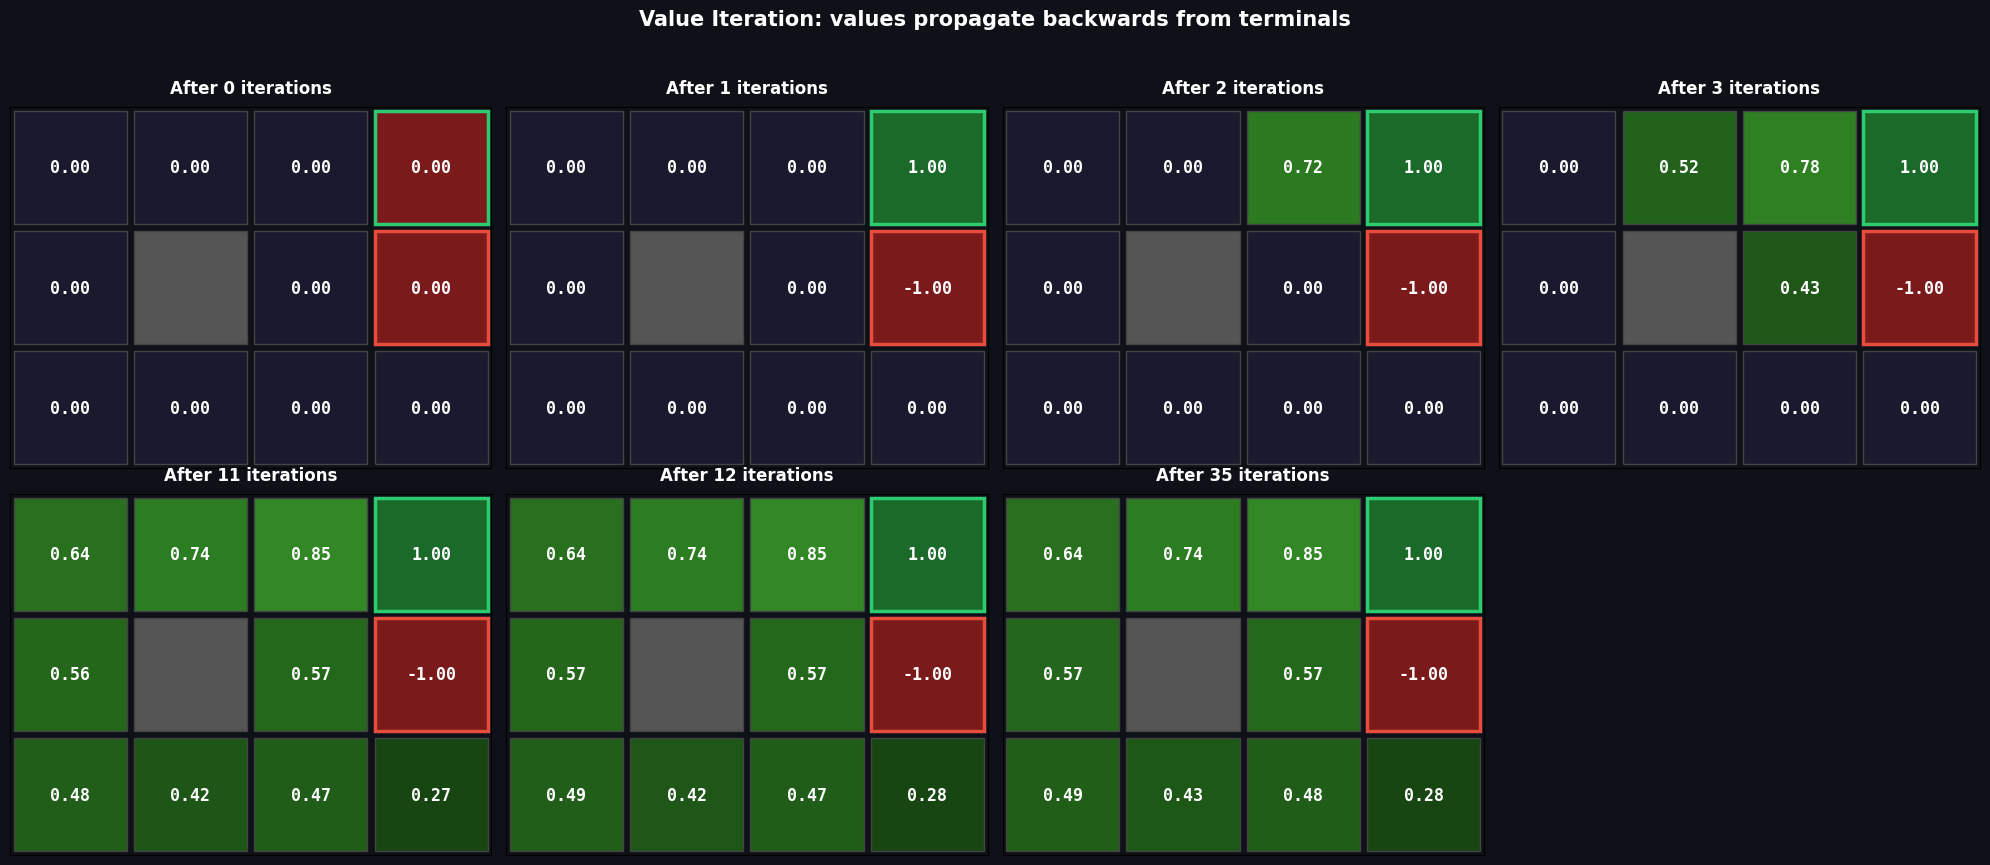

In [8]:
# Value Iteration snapshots (matching the slide progression)
iters = [0, 1, 2, 3, 11, 12, min(100, len(vi_history)-1)]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#0e1117')

for idx, k in enumerate(iters):
    r, c = divmod(idx, 4)
    draw_grid(gw, vi_history[min(k, len(vi_history)-1)],
              ax=axes[r, c], title=f'After {k} iterations', show_labels=False)

axes[1, 3].set_visible(False)
fig.suptitle('Value Iteration: values propagate backwards from terminals',
             fontsize=15, fontweight='bold', color='white', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Extracting the optimal policy

Once we have $V^*$, the optimal policy is:

$$\pi^*(s) = \arg\max_a \sum_{s'} P(s'|s,a)\;\gamma\; V^*(s')$$

Pick the action that leads to the highest expected future value.

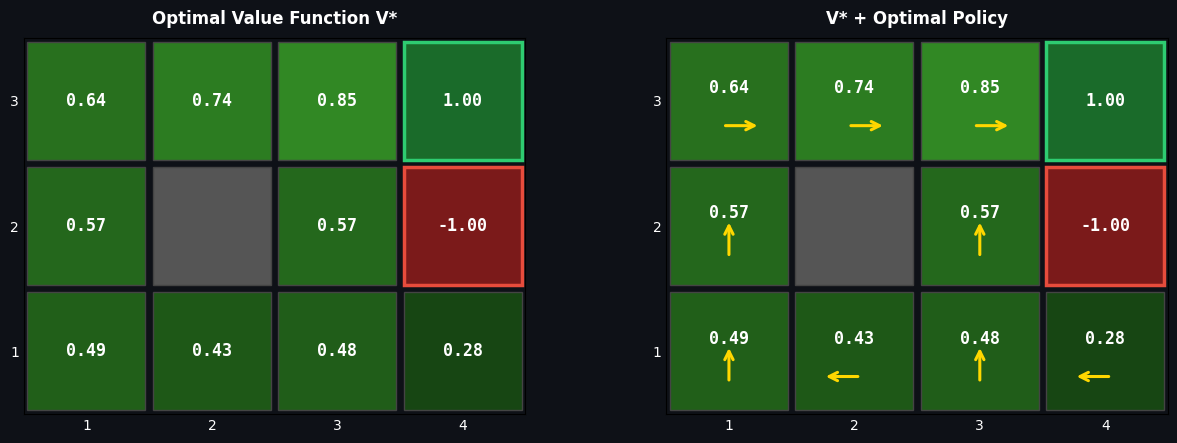

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0e1117')
draw_grid(gw, V_star, ax=axes[0], title='Optimal Value Function V*')
draw_grid(gw, V_star, policy=pi_star, ax=axes[1], title='V* + Optimal Policy')
plt.tight_layout()
plt.show()

---
## Policy Iteration

Instead of updating values toward the *optimal*, alternate between two steps:

**1. Policy Evaluation** -- compute $V^{\pi_k}$ for the current (fixed) policy:

$$V^{\pi_k}(s) \leftarrow \sum_{s'} P(s'|s,\pi_k(s))\;\gamma\; V^{\pi_k}(s')$$

Iterate until convergence. Note: no $\max$ -- the policy is fixed, so this is a linear system.

**2. Policy Improvement** -- find a better policy by being greedy w.r.t. $V^{\pi_k}$:

$$\pi_{k+1}(s) \leftarrow \arg\max_a \sum_{s'} P(s'|s,a)\;\gamma\; V^{\pi_k}(s')$$

Repeat until the policy stops changing. Guaranteed to converge to $\pi^*$.

In [10]:
def policy_evaluation(gw, policy, max_iter=500):
    """Compute V^pi for a given policy. Returns (V, num_iterations)."""
    V = np.zeros((gw.cols, gw.rows))
    for s, r in gw.terminals.items():
        V[s] = r
    for i in range(1, max_iter + 1):
        V_new = np.zeros_like(V)
        for s, r in gw.terminals.items():
            V_new[s] = r
        for s in gw.nonterminal:
            a = policy[s]
            V_new[s] = sum(p * gw.gamma * V[ns]
                           for ns, p in gw.transitions(s, a).items())
        if np.max(np.abs(V_new - V)) < 1e-10:
            break
        V = V_new
    return V_new, i


def policy_iteration(gw, max_iter=20):
    """Run Policy Iteration. Returns (policy, V, history)."""
    policy = np.zeros((gw.cols, gw.rows), dtype=int)  # start: all North
    history = []

    for k in range(max_iter):
        V, eval_iters = policy_evaluation(gw, policy)
        print(f'  Step {k}: policy evaluation converged in {eval_iters} iterations')
        history.append((f'Step {k}', policy.copy(), V.copy()))
        new_policy = extract_policy(gw, V)
        if np.array_equal(new_policy, policy):
            print(f'Policy Iteration converged after {k+1} evaluate-improve cycles')
            break
        policy = new_policy

    return policy, V, history

In [11]:
pi_pi, V_pi, pi_history = policy_iteration(gw)

print(f'Steps recorded: {len(pi_history)}')
for name, pol, V in pi_history:
    match = sum(1 for s in gw.nonterminal if pol[s] == pi_star[s])
    print(f'  {name}: {match}/{len(gw.nonterminal)} actions match V* optimal policy')

  Step 0: policy evaluation converged in 155 iterations
  Step 1: policy evaluation converged in 32 iterations
  Step 2: policy evaluation converged in 34 iterations
Policy Iteration converged after 3 evaluate-improve cycles
Steps recorded: 3
  Step 0: 4/9 actions match V* optimal policy
  Step 1: 8/9 actions match V* optimal policy
  Step 2: 9/9 actions match V* optimal policy


In [12]:
# Step through Policy Iteration: see policy and values evolve
def _show_pi(k):
    name, pol, V = pi_history[min(k, len(pi_history)-1)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor('#0e1117')
    draw_grid(gw, V, ax=axes[0], title=f'{name}: Value Function')
    draw_grid(gw, V, policy=pol, ax=axes[1], title=f'{name}: Policy')
    plt.tight_layout()
    plt.show()

if HAS_WIDGETS:
    widgets.interact(_show_pi,
                     k=widgets.IntSlider(min=0, max=len(pi_history)-1,
                                         step=1, value=0,
                                         description='PI Step:',
                                         style={'description_width': 'initial'},
                                         layout=widgets.Layout(width='80%')))
else:
    for k in range(len(pi_history)):
        _show_pi(k)

interactive(children=(IntSlider(value=0, description='PI Step:', layout=Layout(width='80%'), max=2, style=Slid…

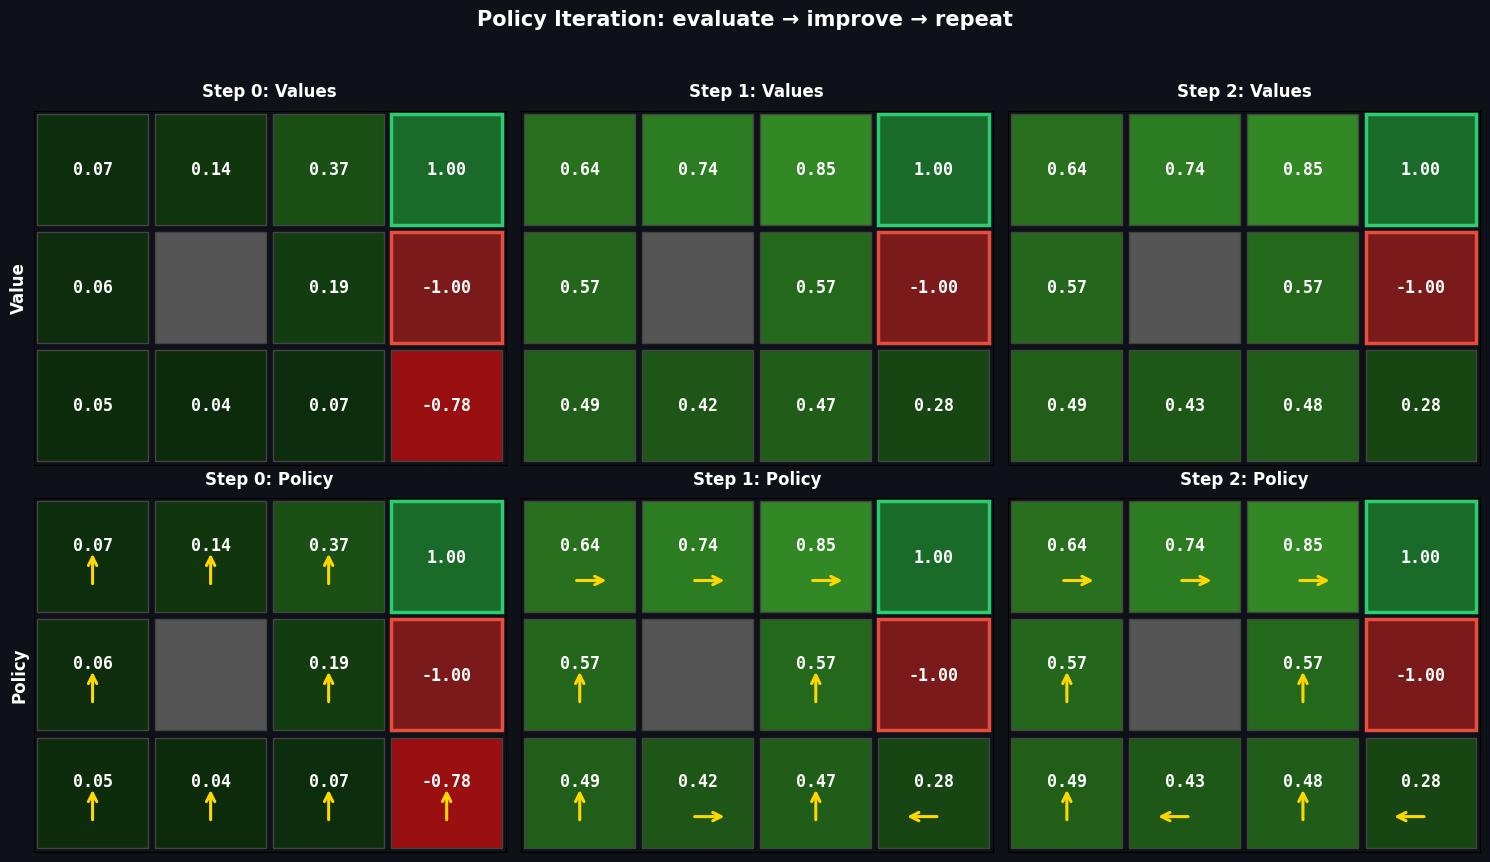

In [13]:
# Policy Iteration: all steps side by side
n = len(pi_history)
fig, axes = plt.subplots(2, n, figsize=(5*n, 9))
fig.patch.set_facecolor('#0e1117')
if n == 1:
    axes = axes.reshape(2, 1)

for k, (name, pol, V) in enumerate(pi_history):
    draw_grid(gw, V, ax=axes[0, k], title=f'{name}: Values', show_labels=False)
    draw_grid(gw, V, policy=pol, ax=axes[1, k], title=f'{name}: Policy', show_labels=False)

axes[0, 0].set_ylabel('Value', color='white', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Policy', color='white', fontsize=12, fontweight='bold')
fig.suptitle('Policy Iteration: evaluate → improve → repeat',
             fontsize=15, fontweight='bold', color='white', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
## Value Iteration vs Policy Iteration

| | Value Iteration | Policy Iteration |
|---|---|---|
| Each step | One Bellman backup per state | Full policy evaluation + improvement |
| Convergence | Many iterations, each cheap | Few iterations, each expensive |
| Policy | Extracted at the end | Updated every step |

Both find the same $V^*$ and $\pi^*$.

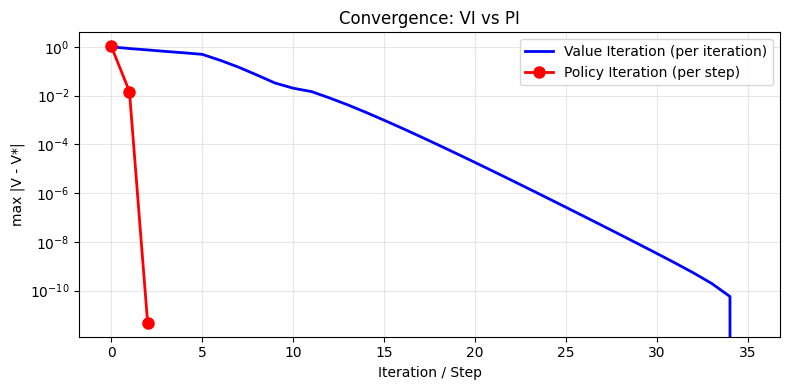

VI: 35 iterations to converge
PI: 3 evaluate-improve steps


In [14]:
# Convergence comparison
vi_err = [np.max(np.abs(vi_history[k] - V_star)) for k in range(len(vi_history))]
pi_err = [np.max(np.abs(V - V_star)) for _, _, V in pi_history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vi_err, 'b-', lw=2, label='Value Iteration (per iteration)')
ax.plot(pi_err, 'ro-', lw=2, ms=8, label='Policy Iteration (per step)')
ax.set_xlabel('Iteration / Step')
ax.set_ylabel('max |V - V*|')
ax.set_title('Convergence: VI vs PI')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'VI: {len(vi_history)-1} iterations to converge')
print(f'PI: {len(pi_history)} evaluate-improve steps')

---
## Experiment: change the parameters

Try different values of **noise** and **discount** and observe how the optimal policy changes:

- `noise = 0`: deterministic transitions -- does the agent risk going near the pit?
- `noise = 0.4`: very slippery floor -- how does the policy adapt?
- `gamma = 0.1`: very myopic agent
- `gamma = 0.99`: far-sighted agent

In [16]:
def run_experiment(noise=0.2, gamma=0.9):
    gw_exp = GridWorld(noise=noise, gamma=gamma)
    V_exp, _ = value_iteration(gw_exp, verbose=False)
    pi_exp = extract_policy(gw_exp, V_exp)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor('#0e1117')
    draw_grid(gw_exp, V_exp, ax=axes[0],
              title=f'V* (noise={noise:.2f}, γ={gamma:.2f})')
    draw_grid(gw_exp, V_exp, policy=pi_exp, ax=axes[1],
              title='Optimal Policy')
    plt.tight_layout()
    plt.show()

if HAS_WIDGETS:
    widgets.interact(run_experiment,
                     noise=widgets.FloatSlider(min=0.0, max=0.5, step=0.05, value=0.2,
                                               description='Noise:'),
                     gamma=widgets.FloatSlider(min=0.1, max=0.99, step=0.01, value=0.9,
                                               description='Gamma:'))
else:
    run_experiment(0.0, 0.9)
    run_experiment(0.4, 0.9)

interactive(children=(FloatSlider(value=0.2, description='Noise:', max=0.5, step=0.05), FloatSlider(value=0.9,…

---
## From V to Q: Why Q-Values?

First, recall the state-value version:

### V-Bellman Equation

$$V^*(s) = \max_a \sum_{s'} P(s'|s,a) \left[R(s,a,s') + \gamma V^*(s')\right]$$

### V-Value Iteration

$$V_{k+1}(s) \leftarrow \max_a \sum_{s'} P(s'|s,a) \left[R(s,a,s') + \gamma V_k(s')\right]$$

With $V^*(s)$, extracting the policy still requires the **transition model**:

$$\pi^*(s) = \arg\max_a \sum_{s'} P(s'|s,a) \left[R(s,a,s') + \gamma V^*(s')\right]$$

We still need $P(s'|s,a)$ to evaluate which action is best. **What if we don't have the model?**

Instead, track the value of each **(state, action)** pair:

$$Q^*(s, a) = \text{expected value of taking action } a \text{ in state } s \text{, then acting optimally}$$

Now the policy is simply: $\pi^*(s) = \arg\max_a Q^*(s, a)$ -- **no extra model lookup for action selection.**

### Q-Bellman Equation

$$Q^*(s, a) = \sum_{s'} P(s'|s,a) \left[R(s,a,s') + \gamma \max_{a'} Q^*(s', a')\right]$$

### Q-Value Iteration

Same idea as Value Iteration, but applied to Q-values:

$$Q_{k+1}(s, a) \leftarrow \sum_{s'} P(s'|s,a) \left[R(s,a,s') + \gamma \max_{a'} Q_k(s', a')\right]$$

Still needs the model $P(s'|s,a)$ for the sum -- but watch what happens next...

In [17]:
def q_value_iteration(gw, max_iter=200):
    """Run Q-Value Iteration. Returns Q*(s, a) table."""
    Q = np.zeros((gw.cols, gw.rows, 4))
    for s, r in gw.terminals.items():
        Q[s[0], s[1], :] = r

    for k in range(1, max_iter + 1):
        Q_new = np.zeros_like(Q)
        for s, r in gw.terminals.items():
            Q_new[s[0], s[1], :] = r
        for s in gw.nonterminal:
            for a in range(4):
                Q_new[s[0], s[1], a] = sum(
                    p * gw.gamma * np.max(Q[ns[0], ns[1]])
                    for ns, p in gw.transitions(s, a).items())
        if np.max(np.abs(Q_new - Q)) < 1e-10:
            print(f'Q-Value Iteration converged at iteration {k}')
            break
        Q = Q_new
    return Q_new


def draw_q_grid(gw, Q, ax=None, title=None):
    """Draw Q-values with 4 triangles per cell (N/E/S/W)."""
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(10, 7.5))
        fig.patch.set_facecolor('#0e1117')
    ax.set_facecolor('#0e1117')

    def _qcolor(val, is_best=False):
        boost = 1.15 if is_best else 0.85
        if val > 0.005:
            t = min(val, 1.0)
            return tuple(min(1, c) for c in
                         (0.04+0.20*t*boost, 0.15+0.50*t*boost, 0.04+0.14*t*boost))
        elif val < -0.005:
            t = min(abs(val), 1.0)
            return tuple(min(1, c) for c in
                         (0.25+0.50*t*boost, 0.06, 0.06))
        return '#1a1a2e'

    for x in range(gw.cols):
        for y in range(gw.rows):
            cx, cy = x + 0.5, y + 0.5
            if (x, y) in gw.walls:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, fc='#555', ec='#333', lw=1))
                continue
            if (x, y) in gw.terminals:
                val = gw.terminals[(x, y)]
                fc = '#1a6b2a' if val > 0 else '#7b1a1a'
                ec = '#2ecc71' if val > 0 else '#e74c3c'
                ax.add_patch(plt.Rectangle((x, y), 1, 1, fc=fc, ec=ec, lw=2.5))
                ax.text(cx, cy, f'{val:.2f}', ha='center', va='center',
                        color='white', fontsize=13, fontweight='bold')
                continue

            # 4 triangles
            tl, tr, br, bl = (x,y+1), (x+1,y+1), (x+1,y), (x,y)
            tri = {0: [tl, tr], 1: [tr, br], 2: [br, bl], 3: [bl, tl]}
            best_a = int(np.argmax(Q[x, y]))
            for a, (c1, c2) in tri.items():
                val = Q[x, y, a]
                fc = _qcolor(val, a == best_a)
                ax.add_patch(plt.Polygon([(cx,cy), c1, c2], fc=fc, ec='#333', lw=0.5))
                dx, dy = GridWorld.DELTAS[a]
                ax.text(cx+dx*0.3, cy+dy*0.3, f'{val:.2f}', ha='center', va='center',
                        color='white', fontsize=7, fontfamily='monospace')

            # V = max Q at center
            ax.text(cx, cy, f'{np.max(Q[x,y]):.2f}', ha='center', va='center',
                    color='#ffd700', fontsize=8, fontweight='bold', fontfamily='monospace',
                    bbox=dict(fc='#0e1117', ec='none', pad=1, alpha=0.7))

    ax.set_xlim(0, gw.cols); ax.set_ylim(0, gw.rows)
    ax.set_aspect('equal')
    ax.set_xticks([i+0.5 for i in range(gw.cols)])
    ax.set_xticklabels(range(1, gw.cols+1), color='white')
    ax.set_yticks([i+0.5 for i in range(gw.rows)])
    ax.set_yticklabels(range(1, gw.rows+1), color='white')
    ax.tick_params(length=0)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=10)

Q-Value Iteration converged at iteration 35
max |V_from_Q - V_star| = 2.35e-11  (should be ~0)

Policy from Q (no model needed):
   →  →  →  T 
   ↑  #  ↑  T 
   ↑  ←  ↑  ← 


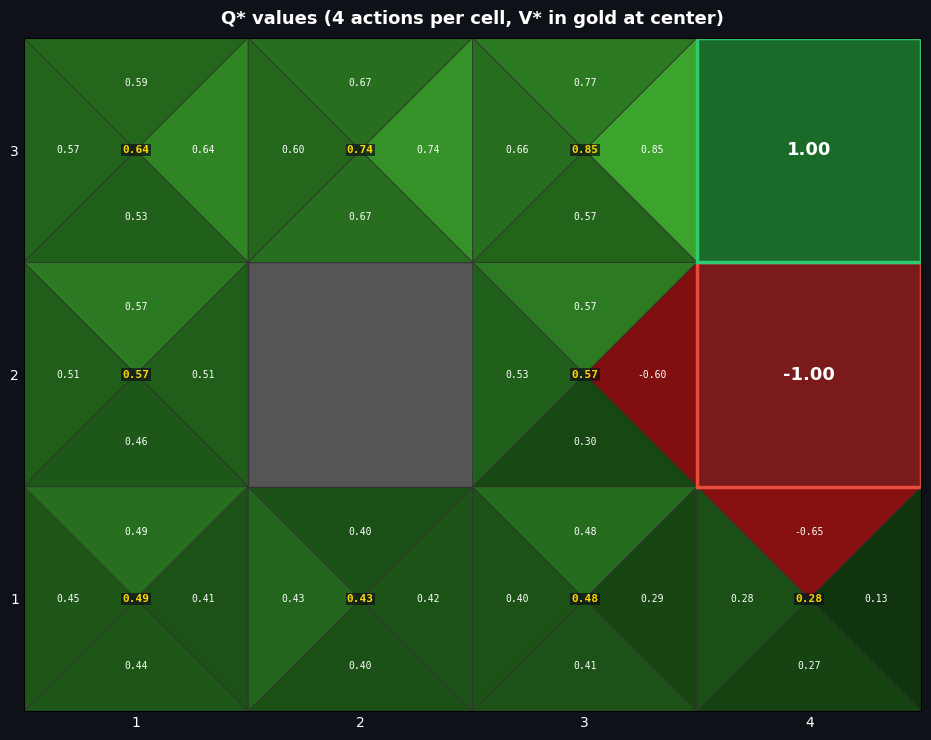

In [18]:
Q_star = q_value_iteration(gw)

# Verify: V from Q should match our earlier V*
V_from_Q = np.max(Q_star, axis=2)
print(f'max |V_from_Q - V_star| = {np.max(np.abs(V_from_Q - V_star)):.2e}  (should be ~0)')
print()

# The key advantage: policy from Q needs NO model
pi_from_Q = np.argmax(Q_star, axis=2)
print('Policy from Q (no model needed):')
for y in range(gw.rows-1, -1, -1):
    row = ''
    for x in range(gw.cols):
        if (x,y) in gw.walls: row += ' # '
        elif (x,y) in gw.terminals: row += ' T '
        else: row += f' {arrows[pi_from_Q[x,y]]} '
    print(f'  {row}')

fig, ax = plt.subplots(figsize=(10, 7.5))
fig.patch.set_facecolor('#0e1117')
draw_q_grid(gw, Q_star, ax=ax, title='Q* values (4 actions per cell, V* in gold at center)')
plt.tight_layout()
plt.show()

## Tabular Q-Learning: Drop the Model

Q-Value Iteration still has $\sum_{s'} P(s'|s,a)$ in the update -- the model is right there in the formula.

**Key insight:** rewrite the sum as an expectation, then replace it with a single sample:

$$Q_{k+1}(s,a) \leftarrow \underbrace{\sum_{s'} P(s'|s,a)}_{\text{need model}} \Big[\gamma\;\max_{a'} Q_k(s', a')\Big]
= \mathbb{E}_{s' \sim P}\Big[\gamma\;\max_{a'} Q_k(s', a')\Big]$$

**Q-Learning update** (replace expectation with one sample):
1. Take action $a$ in state $s$, observe next state $s'$
2. Compute target: $\;\text{target} = \gamma\;\max_{a'} Q(s', a')$
3. Running average: $\;Q(s,a) \leftarrow (1-\alpha)\,Q(s,a) + \alpha\;\text{target}$

No model, no sweeping all states. Just interact and learn.

**Notes:**
- **$\varepsilon$-greedy:** with prob $\varepsilon$ take random action, otherwise greedy -- ensures exploration
- **Off-policy:** converges to $Q^*$ even while acting suboptimally
- **Learning rate decay:** $\alpha$ must decrease over time for convergence (we use $\alpha = 10/(10 + n)$ where $n$ is the visit count)
- **Random starts:** episodes begin from random states to ensure all regions are explored

In [19]:
def grid_step(gw, state, action, rng):
    """Simulate one step (samples from transition model -- agent does NOT see P).
    
    No explicit reward signal: terminal values are baked into Q-table
    initialization, matching the VI formulation where V(terminal) = r.
    """
    trans = gw.transitions(state, action)
    states, probs = zip(*trans.items())
    ns = states[rng.choice(len(states), p=probs)]
    done = ns in gw.terminals
    return ns, done


def q_learning(gw, n_episodes=15000, gamma=None,
               eps_start=1.0, eps_end=0.01, eps_decay=0.9995, seed=42):
    """Tabular Q-Learning on the grid world.
    
    Uses the same Bellman structure as Q-VI:
        target = gamma * max_a' Q(s', a')
    but replaces the full expectation with a single sample.
    
    Terminal Q-values are initialized to their true values (same as Q-VI)
    and never updated.
    """
    if gamma is None:
        gamma = gw.gamma
    rng = np.random.default_rng(seed)
    Q = np.zeros((gw.cols, gw.rows, 4))
    # Fix terminal Q = r (same as Q-VI), never update them
    for s, r in gw.terminals.items():
        Q[s[0], s[1], :] = r
    N_sa = np.zeros((gw.cols, gw.rows, 4))  # visit counts for decaying alpha
    epsilon = eps_start
    ep_rewards = []

    for ep in range(n_episodes):
        # Random start: ensures all states are explored
        s = gw.nonterminal[rng.integers(len(gw.nonterminal))]
        reached_terminal = None
        for _ in range(200):
            # epsilon-greedy
            if rng.random() < epsilon:
                a = rng.integers(4)
            else:
                a = int(np.argmax(Q[s[0], s[1]]))

            ns, done = grid_step(gw, s, a, rng)

            # Q-learning update: target = gamma * max Q(s')
            target = gamma * np.max(Q[ns[0], ns[1]])
            N_sa[s[0], s[1], a] += 1
            alpha = 10.0 / (10.0 + N_sa[s[0], s[1], a])  # decaying LR
            Q[s[0], s[1], a] += alpha * (target - Q[s[0], s[1], a])

            if done:
                reached_terminal = ns
                break
            s = ns

        epsilon = max(eps_end, epsilon * eps_decay)
        ep_rewards.append(gw.terminals.get(reached_terminal, 0.0)
                          if reached_terminal else 0.0)

    return Q, ep_rewards

Policy from Q-learning (learned WITHOUT the model):
   →  →  →  T 
   ↑  #  ↑  T 
   ↑  ←  ↑  ← 
Actions matching V* optimal: 9/9


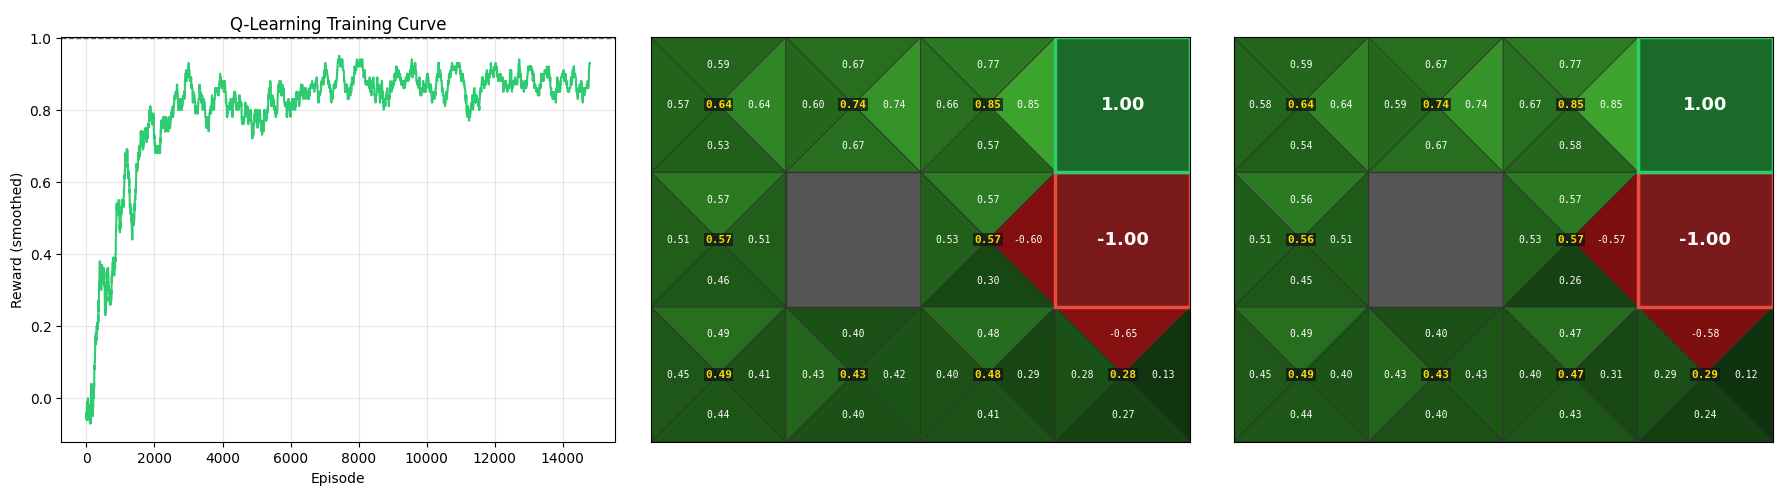

In [20]:
Q_ql, ql_rewards = q_learning(gw, n_episodes=15000)

# Policy from Q-learning
pi_ql = np.argmax(Q_ql, axis=2)

print('Policy from Q-learning (learned WITHOUT the model):')
for y in range(gw.rows-1, -1, -1):
    row = ''
    for x in range(gw.cols):
        if (x,y) in gw.walls: row += ' # '
        elif (x,y) in gw.terminals: row += ' T '
        else: row += f' {arrows[pi_ql[x,y]]} '
    print(f'  {row}')

match = sum(1 for s in gw.nonterminal if pi_ql[s] == pi_star[s])
print(f'Actions matching V* optimal: {match}/{len(gw.nonterminal)}')

# Training curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Reward per episode (smoothed)
window = 200
smoothed = np.convolve(ql_rewards, np.ones(window)/window, mode='valid')
axes[0].plot(smoothed, color='#2ecc71', lw=1.5)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward (smoothed)')
axes[0].set_title('Q-Learning Training Curve')
axes[0].axhline(y=1.0, color='#666', ls='--', lw=1)
axes[0].grid(True, alpha=0.3)

# 2. Q-values from Q-Value Iteration (exact, needs model)
draw_q_grid(gw, Q_star, ax=axes[1], title='Q-Value Iteration (exact, needs model)')

# 3. Q-values from Q-Learning (approximate, model-free)
draw_q_grid(gw, Q_ql, ax=axes[2], title='Q-Learning (learned, no model)')

plt.tight_layout()
plt.show()

### Q-Learning vs Q-Value Iteration

The Q-values converge to near-identical values, and the **optimal policy matches exactly**. The critical difference is *how* they're computed:

| | Q-Value Iteration | Q-Learning |
|---|---|---|
| Needs model $P(s'\|s,a)$? | Yes | **No** |
| Sweeps all states? | Yes | **No** -- only visits reachable states |
| How it learns | Full Bellman backup | Single-sample TD update |

Q-learning recovers the optimal policy **purely from interaction** -- no transition model, no teleportation, no state enumeration.

This is what makes Q-learning powerful: it works even when $P(s'|s,a)$ is unknown. But it still uses a **table** with one entry per (state, action) pair. Can that scale?

$\rightarrow$ **See the crawler notebook** for what happens when the state space grows from $10^1$ to $10^4$ -- and why we need **DQN**.

---
## Key Takeaways

**What we covered:**
- **Value Iteration** and **Policy Iteration** find $V^*$ and $\pi^*$ for this small grid
- Values propagate backwards from terminals -- watch the "wave" in the slider
- **Q-values** let us extract the policy **without the model**: $\pi^*(s) = \arg\max_a Q^*(s,a)$
- **Q-learning** recovers $Q^*$ purely from interaction -- no model, no state enumeration

**Limitations of exact/tabular methods** (motivating what comes next):
1. Must **sweep all states** (VI/PI) or **visit them enough** (Q-learning) -- infeasible for large state spaces
2. VI/PI need the **transition model** $P(s'|s,a)$ -- Q-learning fixes this
3. Q-learning still needs a **table** -- can't scale beyond ~$10^4$ states
4. Must have the **right state representation** -- we'll see this break on the crawler

$\rightarrow$ **DQN** replaces the Q-table with a neural network to handle continuous/large state spaces.